In [1]:
from __future__ import annotations

import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

idx = pd.IndexSlice

In [2]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

# inplace update: give these gas-ish techs a more diverse palette (not all brown)
tech_colors.update({
    "SMR CC":                  "#1f77b4",  # blue
    "heat100-200 industry gas": "#ff7f0e",  # orange
    "heat<100 industry gas":    "#2ca02c",  # green
    "Combined-Cycle Gas":       "#d62728",  # red
    "Open-Cycle Gas":           "#9467bd",  # purple
    "heat200-500 industry gas": "#17becf",  # cyan
    "SMR":                      "#e377c2",  # pink
    "urban central gas boiler": "#7f7f7f",  # grey
    "urban central gas CHP":    "#bcbd22",  # olive
    "rural gas boiler":         "#8c564b",  # brown (keep one brown, but not all)
    "urban decentral gas boiler":"#aec7e8", # light blue
    "urban decentral biomass boiler":"#92648c", # purple
    "rural biomass boiler":"#94312c", # purple
    "heat>500 industry gas":    "#98df8a",  # light green
    "gas DRI":    "#000000",  # light green
})
tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']


In [3]:
nb = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'nodal_energy_balance.csv', index_col=list(range(4)), header=list(range(5))
).loc[:,idx[:,:,:,'free']]
nb.columns = nb.columns.get_level_values(-1).astype(int)

In [4]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

In [5]:
mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'free']]
mp.columns = mp.columns.get_level_values(-1).astype(int)

gas_price = mp.loc['gas']
gas_price.index = gas_price.index.get_level_values(-1)

In [6]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [7]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = mp.columns[-1] # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

ignored = [
    'gas for industry CC',
    'gas for industry',
    ]

df.drop(ignored, inplace=True)

df['gas_consumption'] = gasuse_baseline - df['phase_out_volume']
xlim_lower = 1000
xlim_upper = 4000

In [8]:
def find_upward_transition_column(
    df: pd.DataFrame,
    *,
    heuristic: str = "peak_slope",     # "peak_slope" | "first_nonzero"
    min_rel_change: float = 0.5,       # return NaN if row range < min_rel_change * row_max
    zero_tol: float = 0.0,             # used for "first_nonzero"
) -> pd.Series:
    """
    For each row in df, return the column label where the *upward* transition occurs.

    - heuristic="peak_slope": pick the column where the positive discrete slope (diff) is maximal.
      (Downward slopes are ignored.)
    - heuristic="first_nonzero": pick the first column where the row value becomes non-zero ( > zero_tol ).

    Special cases:
    - If a row does not change by at least `min_rel_change` of its own max value,
      return NaN (i.e. approximately constant rows).
    - If there is no upward slope (all diffs <= 0), return NaN.

    Returns
    -------
    pd.Series
        Index = df.index (row names), values = df.columns label (can be MultiIndex value) or NaN.
    """
    if heuristic not in {"peak_slope", "first_nonzero"}:
        raise ValueError("heuristic must be one of {'peak_slope', 'first_nonzero'}")

    cols = df.columns
    out = []

    for _, row in df.iterrows():
        x = row.to_numpy(dtype=float)

        # robust-ish NaN handling
        if np.all(np.isnan(x)):
            out.append(np.nan)
            continue

        row_max = np.nanmax(x)
        row_min = np.nanmin(x)

        # constant-ish rows (or all-zero rows)
        if not np.isfinite(row_max) or row_max <= 0:
            out.append(np.nan)
            continue
        if (row_max - row_min) < (min_rel_change * row_max):
            out.append(np.nan)
            continue

        if heuristic == "first_nonzero":
            mask = x > zero_tol
            if not np.any(mask):
                out.append(np.nan)
            else:
                j = int(np.argmax(mask))  # first True
                out.append(cols[j])
            continue

        # heuristic == "peak_slope"
        if len(x) < 2:
            out.append(np.nan)
            continue

        d = np.diff(x)
        d_pos = np.where(d > 0, d, -np.inf)  # ignore downward/flat slopes
        if not np.any(np.isfinite(d_pos)):
            out.append(np.nan)
            continue

        j = int(np.nanargmax(d_pos))
        if not np.isfinite(d_pos[j]) or d_pos[j] <= 0:
            out.append(np.nan)
        else:
            # diff between cols[j] -> cols[j+1]; return the "arrival" column
            out.append(cols[j + 1])

    return pd.Series(out, index=df.index, name="transition_column").dropna().astype(int)

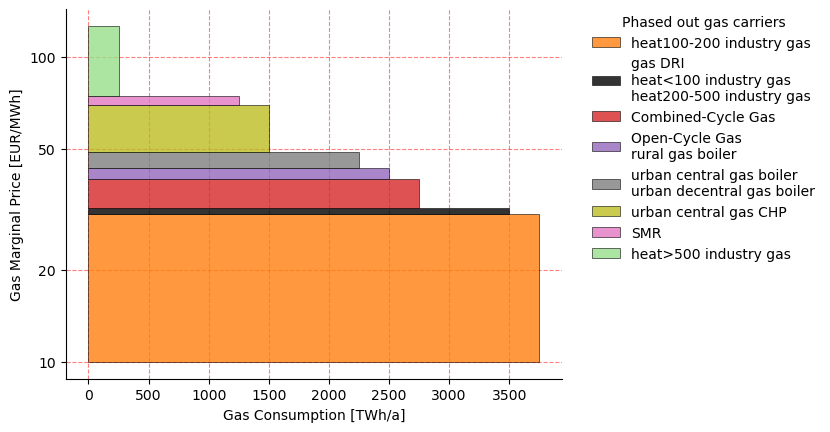

In [9]:
xlim_lower = 0

fig, ax = plt.subplots()

labels, handles = [], []

for i, price in enumerate(df['phase_out_prices'].unique()):

    ss = df.loc[df['phase_out_prices'] == price]

    if i == 0:
        lower = 10
    else:
        lower = upper

    upper = price
    text = '\n'.join(ss.index)

    #usage = ss['phase_out_volume'].max()
    usage = ss['gas_consumption'].max()
    ax.fill_between([xlim_lower, usage], lower, upper, alpha=0.8, label=text, color=tech_colors[ss.index[0]], edgecolor='black', linewidth=0.5)

    # ax.text(usage + 50, (lower + upper) / 2, text, ha='left', va='center', fontsize=10)

ax.set_yscale('symlog', linthresh=10)
# ax.set_ylim(10, df['phase_out_prices'].max() * 1.1)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Phased out gas carriers', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# ax.set_xlim(xlim_lower, xlim_upper)

ax.grid(linestyle='--', alpha=0.5, color='red')
ax.set_axisbelow(True)

ax.set_yticks([10, 20, 50, 100])
ax.set_yticklabels(['10', '20', '50', '100'])

ax.set_xlabel('Gas Consumption [TWh/a]')
ax.set_ylabel('Gas Marginal Price [EUR/MWh]')

plt.show()

heat100-200 industry gas
gas DRI
heat<100 industry gas
heat200-500 industry gas
Combined-Cycle Gas
Open-Cycle Gas
rural gas boiler
urban central gas boiler
urban decentral gas boiler
urban central gas CHP
SMR
heat>500 industry gas


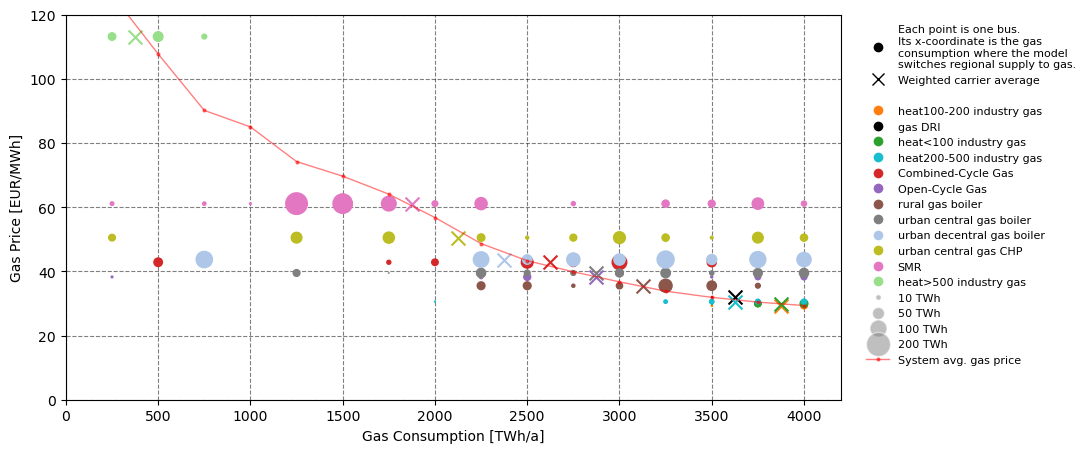

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

idx = pd.IndexSlice

bus_carriers = {
    'heat>500 industry gas': 'heat>500 industry',
    'heat200-500 industry gas': 'heat200-500 industry',
    'SMR': 'Hydrogen Storage',
    'heat100-200 industry gas': 'heat100-200 industry',
    'heat<100 industry gas': 'heat<100 industry',
    'Combined-Cycle Gas': 'AC',
    'Open-Cycle Gas': 'AC',
    'urban central gas boiler': 'urban central heat',
    'urban central gas CHP': 'urban central heat',
    'rural gas boiler': 'rural heat',
    'urban decentral gas boiler': 'urban decentral heat',
}
scaling = 1.5
gprice = mp.loc['gas']

balance_data = []
phaseout_points_data = []

for carrier in df.index:
    print(carrier)

    bus_carrier = bus_carriers.get(carrier, carrier)

    # ss = nb.loc[idx[:,carrier,:,bus_carrier]]
    ss = nb.loc[idx[:,carrier,:,'gas']].abs()
    ss.index = ss.index.droplevel(0)

    balance_data.append(ss)

    phaseouts = find_upward_transition_column(ss).dropna()
    s = ss.loc[phaseouts.index].max(axis=1).mul(1e-6)
    weights = s.div(s.sum())

    gprice_ss = gprice.loc[phaseouts.values]

    weighted_avg_price = (gprice_ss * weights.values).sum()#  / s.mean()
    prices = [weighted_avg_price for _ in range(len(s))]

    # print(phaseouts)
    # print

    ax.scatter(
        phaseouts.values,
        prices,
        s=s.values * scaling,
        color=tech_colors[carrier]
        )
    
    phaseout_points_data.append(phaseouts.rename(carrier))

    hold = pd.Series(gprice.index, index=gprice.values)
    hold.loc[weighted_avg_price] = np.nan
    hold.sort_index(inplace=True)
    con = hold.interpolate().loc[weighted_avg_price]

    ax.scatter(
        con,
        weighted_avg_price,
        s=100,
        color=tech_colors[carrier],
        marker='x'
    )

ax.plot(
    nb.columns,
    mp.loc['gas', nb.columns],
    color='red',
    alpha=0.5,
    linewidth=1,
    marker='o',
    markersize=2
)

ax.set_xlim(nb.columns[0] * .95, nb.columns[-1] * 1.05)
ax.set_ylim(0, 120)

ax.set_xlabel('Gas Consumption [TWh/a]')

# Create legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

legend_elements.append(
    Line2D([0], [0], marker='o', color='w', 
            markerfacecolor='k',
            markersize=8, label='Each point is one bus.\nIts x-coordinate is the gas\nconsumption where the model\nswitches regional supply to gas.')
)
legend_elements.append(
    Line2D([0], [0], marker='x', color='w', 
            markerfacecolor='k',
            markeredgecolor='k',
            markersize=8, label='Weighted carrier average')
)

legend_elements.append(
    Line2D([0], [0], marker='o', color='w', 
            markerfacecolor='w',
            markeredgecolor='w',
            markersize=8, label='')
)

# Add carrier colors as points
for carrier in df.index:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=tech_colors[carrier], 
               markersize=8, label=carrier)
    )

# Add size indicators in grey
size_values = [10, 50, 100, 200]  # TWh
for size in size_values:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='grey', alpha=0.5,
               markersize=np.sqrt(size * scaling),
               label=f'{size} TWh')
    )

# Add red line for system average gas price
legend_elements.append(
    Line2D([0], [0], color='red', alpha=0.5,
           linewidth=1, marker='o', markersize=2,
           label='System avg. gas price')
)

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          framealpha=0.9, fontsize=8, ncol=1)

ax.set_ylabel('Gas Price [EUR/MWh]')
ax.grid(linestyle='--', alpha=0.5, color='k')
ax.set_axisbelow(True)

plt.show()

##### energy balances

In [11]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

In [12]:
costs = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'costs.csv', index_col=list(range(3)), header=list(range(5))
).sum().mul(1e-9)
costs.index = costs.index.get_level_values(-1)
# Interpolate value for 1750 instead of dropping it
if '1750' in costs.index:
    i = costs.index.get_loc('1750')
    if i > 0 and i < len(costs) - 1:
        prev_val = costs.iloc[i - 1]
        next_val = costs.iloc[i + 1]
        costs.iloc[i] = (prev_val + next_val) / 2
costs.name = 'System Cost [B€]'
costs.index.name = 'Gas Consumption [TWh/a]'

In [13]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    # "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

Index(['Combined-Cycle Gas', 'Open-Cycle Gas', 'SMR', 'Sabatier',
       'biogas to gas', 'gas DRI', 'gas for industry', 'gas for industry CC',
       'heat100-200 industry gas', 'heat200-500 industry gas',
       'heat<100 industry gas', 'heat>500 industry gas', 'rural gas boiler',
       'urban central gas CHP', 'urban central gas boiler',
       'urban decentral gas boiler'],
      dtype='object', name='carrier')


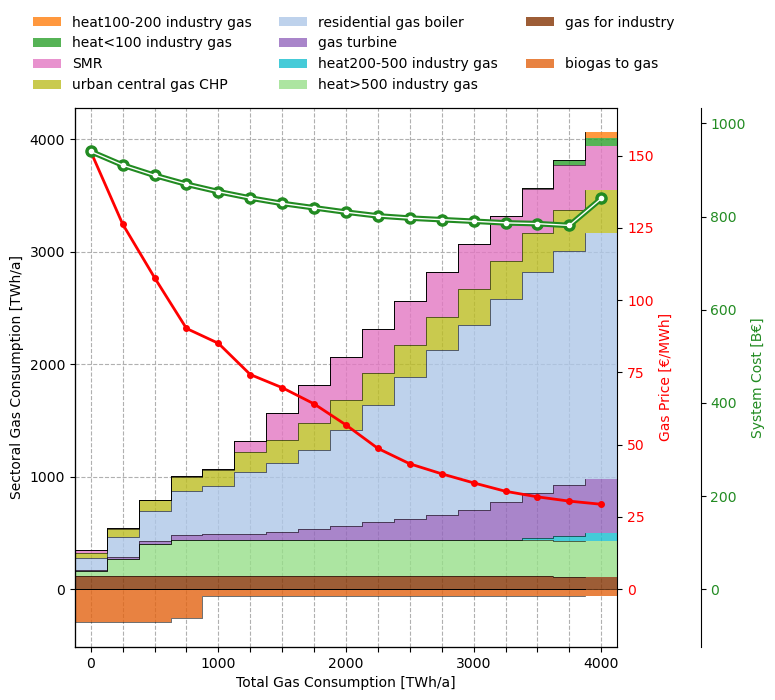

In [ ]:
print(gb.index)
carrier_mapping = {
    'urban decentral gas boiler': 'residential gas boiler',
    'urban central gas boiler': 'residential gas boiler',
    'rural gas boiler': 'residential gas boiler',
    'Open-Cycle Gas': 'gas turbine',
    'Combined-Cycle Gas': 'gas turbine',
}

for carrier in items:
    if carrier in carrier_mapping:
        continue

    carrier_mapping[carrier] = carrier_mapping.get(carrier, carrier)

gb = gb.groupby(carrier_mapping).sum()

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=gb.columns, dtype=float)
ceilings = pd.Series(0, index=gb.columns, dtype=float)

width = 1

for i, carrier in enumerate(items):

    row = gb.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            ax.bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

        else:

            ax.bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value
    
    ax.step(
        np.arange(len(bottoms)),# + width/2,
        bottoms.values,
        where='post',
        **line_kwargs
    )
    ax.step(
        np.arange(len(bottoms)),# + width/2,
        ceilings.values,
        where='post',
        **line_kwargs
    )

ax.set_xlim(-width/2, len(bottoms) - width/2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(linestyle='--', alpha=1)
ax.set_axisbelow(True)

ax.set_xticks(np.arange(len(bottoms)) + width/2)
ax.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in items[::-1]:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

from matplotlib.lines import Line2D

handles.append(Line2D([0], [0], color='w', lw=0.5, alpha=0.8))
labels.append('')

labels.append('biogas to gas')
handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors['biogas to gas'], alpha=0.8))

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(-0.1, 1.1), frameon=False, ncol=3)

ax.set_xlabel('Total Gas Consumption [TWh/a]')
ax.set_ylabel('Sectoral Gas Consumption [TWh/a]')

ax2 = ax.twinx()

y1_min, y1_max = ax.get_ylim()

if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

gas_price_min = gas_price.min()
gas_price_max = gas_price.max()

y2_max = gas_price_max * 1.1  # Add 10% padding at the top

if zero_fraction < 1:
    y2_min = -zero_fraction * y2_max / (1 - zero_fraction)
else:
    y2_min = gas_price_min * 0.9  # Fallback if zero_fraction is 1

ax2.plot(np.arange(len(gas_price)) + width/2, gas_price.values, color='red', linewidth=2, marker='o', markersize=4)
ax2.set_xlim(0, len(bottoms))
ax2.set_ylim(y2_min, y2_max)
ax2.set_ylabel('Gas Price [€/MWh]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add third y-axis for costs
ax3 = ax.twinx()

# Offset the third axis to the right
ax3.spines['right'].set_position(('outward', 60))

costs_min = costs.min()
costs_max = costs.max()

y3_max = costs_max * 1.1  # Add 10% padding at the top

if zero_fraction < 1:
    y3_min = -zero_fraction * y3_max / (1 - zero_fraction)
else:
    y3_min = costs_min * 0.9  # Fallback if zero_fraction is 1

cost_color = 'forestgreen'
# ax3.plot(np.arange(len(costs)) + width/2, costs.values, color=cost_color, linewidth=2, marker='o', markersize=4)
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color=cost_color, linewidth=4, marker='o', markersize=8)
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color='w', linewidth=1, marker='o', markersize=3)
ax3.set_xlim(0, len(bottoms))
ax3.set_ylim(y3_min, y3_max)
ax3.set_ylabel('System Cost [B€]', color=cost_color)
ax3.tick_params(axis='y', labelcolor=cost_color)

plt.savefig('gas_use_by_sector.pdf', bbox_inches='tight')
plt.show()

In [15]:
target_bus_carriers = {
    "Hydrogen Storage": ["SMR"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas"],
    "gas": ["Sabatier"],
    "biogas": ["biogas to gas"],
    "gas for industry": ["gas for industry", "gas for industry CC"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat<100 industry": ["heat<100 industry gas"],
    "heat>500 industry": ["heat>500 industry gas"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
}

gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

# gb = bal.loc[:,:,'gas'].mul(1e-6)

threshold = 10 # TWh

displacers = []

# for bus_carrier, gas_carrier in gb.index:
for bus_carrier, gas_carriers in target_bus_carriers.items():
# for carrier in ['heat100-200 industry gas']:

    # if carrier in ['gas for industry', 'gas for industry CC', 'Sabatier']:
    #     continue

    # target_carrier = target_bus_carriers[carrier]

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    # print(ss)
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    # print()
    diff = diff.loc[diff.sum(axis=1) > threshold]

    print(bus_carrier)
    print(gas_carriers)
    print(diff.index)
    print('===================================')

    displacers.append(diff)

Hydrogen Storage
['SMR']
Index(['H2 Electrolysis'], dtype='object', name='carrier')
AC
['Combined-Cycle Gas', 'Open-Cycle Gas']
Index(['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Onshore Wind',
       'solar-hsat', 'battery discharger', 'gas pipeline',
       'urban central solid biomass CHP'],
      dtype='object', name='carrier')
gas
['Sabatier']
Index([], dtype='object', name='carrier')
biogas
['biogas to gas']
Index(['biogas'], dtype='object', name='carrier')
gas for industry
['gas for industry', 'gas for industry CC']
Index([], dtype='object', name='carrier')
heat100-200 industry
['heat100-200 industry gas']
Index(['heat100-200 industry industrial heat pump high temperature'], dtype='object', name='carrier')
heat200-500 industry
['heat200-500 industry gas']
Index(['heat200-500 industry solid biomass'], dtype='object', name='carrier')
heat<100 industry
['heat<100 industry gas']
Index(['heat<100 industry industrial heat pump medium temperature'], dtype='object', name='carrier')
hea

In [16]:
df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
df.index

ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

# df.drop(['gas', 'biogas'], inplace=True)

df = df.groupby(df.index).sum()

df.index
df.drop('gas pipeline', inplace=True)

In [17]:
sorted_displacers_index = [
    # "biogas to gas",
    # "Fischer-Tropsch",
    # "electrobiofuels",
    "heat<100 industry industrial heat pump medium temperature",
    "heat100-200 industry industrial heat pump high temperature",
    "battery discharger",
    "air heat pump",
    "ground heat pump",
    "urban central solid biomass CHP",
    "urban decentral biomass boiler",
    "rural biomass boiler",
    "heat200-500 industry solid biomass",
    # "electrobiofuels",
    "H2 Electrolysis",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    # "Offshore Wind (Floating)",
    "Onshore Wind",
    # "Solar",
    "solar-hsat",
    "solar thermal",
    "biogas",
    # "heat200-500 industry hydrogen",
    "heat>500 industry hydrogen",
]

In [18]:
# set(sorted_displacers_index) == set(df.index)
pd.Index(sorted_displacers_index).difference(df.index)

Index([], dtype='object')

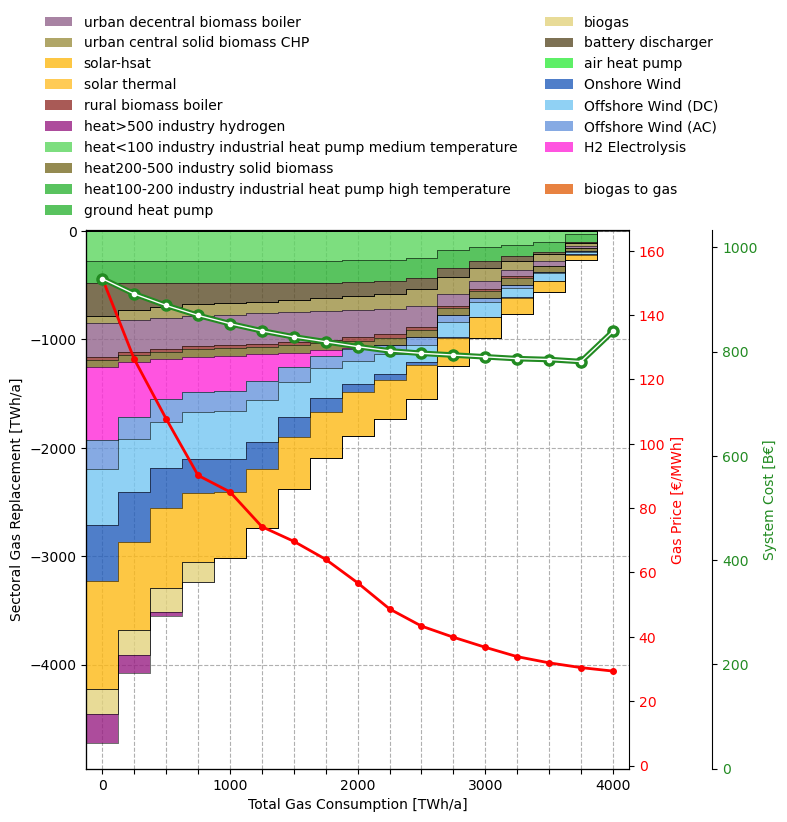

In [19]:
line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=df.columns, dtype=float)
ceilings = pd.Series(0, index=df.columns, dtype=float)

width = 1

assert df.index.symmetric_difference(sorted_displacers_index).empty, df.index.symmetric_difference(sorted_displacers_index)

# for i, carrier in enumerate(df.index):
for i, carrier in enumerate(sorted_displacers_index):

    row = df.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            ax.bar(
                j + width/2,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

            # ax.plot(
            #     [j-width/2, j+width/2],
            #     [ceilings.loc[con], ceilings.loc[con]],
            #     **line_kwargs
            # )

        else:

            ax.bar(
                j + width/2,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value

            # ax.plot(
            #     [j-width/2, j+width/2],
            #     [bottoms.loc[con], bottoms.loc[con]],
            #     **line_kwargs
            # )
    
    ax.step(
        np.arange(len(bottoms)),
        bottoms.values,
        where='post',
        **line_kwargs
    )
    ax.step(
        np.arange(len(bottoms)),
        ceilings.values,
        where='post',
        **line_kwargs
    )

ax.set_xlim(-width/2, len(bottoms) - width/2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(linestyle='--', alpha=1)
ax.set_axisbelow(True)

ax.set_xticks(np.arange(len(bottoms)) + width/2)
ax.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in df.index[::-1]:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)


from matplotlib.lines import Line2D

handles.append(Line2D([0], [0], color='w', lw=0.5, alpha=0.8))
labels.append('')

labels.append('biogas to gas')
handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors['biogas to gas'], alpha=0.8))

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(-.1, 1.21), frameon=False, ncol=2)

ax.set_xlabel('Total Gas Consumption [TWh/a]')
ax.set_ylabel('Sectoral Gas Replacement [TWh/a]')

ax2 = ax.twinx()

y1_min, y1_max = ax.get_ylim()

if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

gas_price_min = gas_price.min()
gas_price_max = gas_price.max()

y2_max = gas_price_max * 1.1  # Add 10% padding at the top

if zero_fraction < 1:
    y2_min = -zero_fraction * y2_max / (1 - zero_fraction)
else:
    y2_min = gas_price_min * 0.9  # Fallback if zero_fraction is 1

ax2.plot(np.arange(len(gas_price)) + width/2, gas_price.values, color='red', linewidth=2, marker='o', markersize=4)
# ax2.set_xlim(-width/2, len(bottoms) - width/2)
ax2.set_xlim(0, len(bottoms))
ax2.set_ylim(-1, y2_max)
ax2.set_ylabel('Gas Price [€/MWh]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add third y-axis for costs
ax3 = ax.twinx()

# Offset the third axis to the right
ax3.spines['right'].set_position(('outward', 60))

y1_min, y1_max = ax.get_ylim()

if y1_min < 0 < y1_max:
    zero_fraction = -y1_min / (y1_max - y1_min)
else:
    zero_fraction = 0  # If y=0 is not in range, default to bottom

costs_min = costs.min()
costs_max = costs.max()

y3_max = costs_max * 1.1  # Add 10% padding at the top

# if zero_fraction < 1:
#     y3_min = -zero_fraction * y3_max / (1 - zero_fraction)
# else:
# y3_min = costs_min * 0.9  # Fallback if zero_fraction is 1
y3_min = 0

cost_color = 'forestgreen'
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color=cost_color, linewidth=4, marker='o', markersize=8)
ax3.plot(np.arange(len(costs)) + width/2, costs.values, color='w', linewidth=1, marker='o', markersize=3)
ax3.set_xlim(0, len(bottoms))
ax3.set_ylim(y3_min, y3_max)
ax3.set_ylabel('System Cost [B€]', color=cost_color)
ax3.tick_params(axis='y', labelcolor=cost_color)

plt.show()

In [112]:
costs.max()

939.7074387349785

In [116]:
y3_min

-537757.3825513114